In [1]:
import os
import jax
from jax import numpy as np, tree as jtu, random as jr, scipy as sp

import equinox as eqx
from kneed import KneeLocator
from dLux import utils as dlu
from optax import sgd, adam, linear_schedule, apply_updates

import amigo as amg
from amigo import plotting
import dorito as drt
from dorito.stats import disco_regularised_loss_fn

from tqdm.notebook import tqdm
import time

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

In [2]:
from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.utils import normalize_image, mas2rad
from frito.simulate import inject_image, image2ComplexVis

In [138]:
master_key = jr.key(0)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"]
# test_51x51_data = np.clip(
#     test_51x51_data / np.max(test_51x51_data, axis=(1, 2), keepdims=True),
#     min=1e-8,
# )
test_51x51_data = np.clip(test_51x51_data, min=1e-8)
test_51x51_image = test_51x51_data[225]

disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()

In [139]:
model_key, master_key = jr.split(master_key, 2)
model_type = "PPD"
i = 0
model_names = ["7_4"]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"model_{model_name}.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


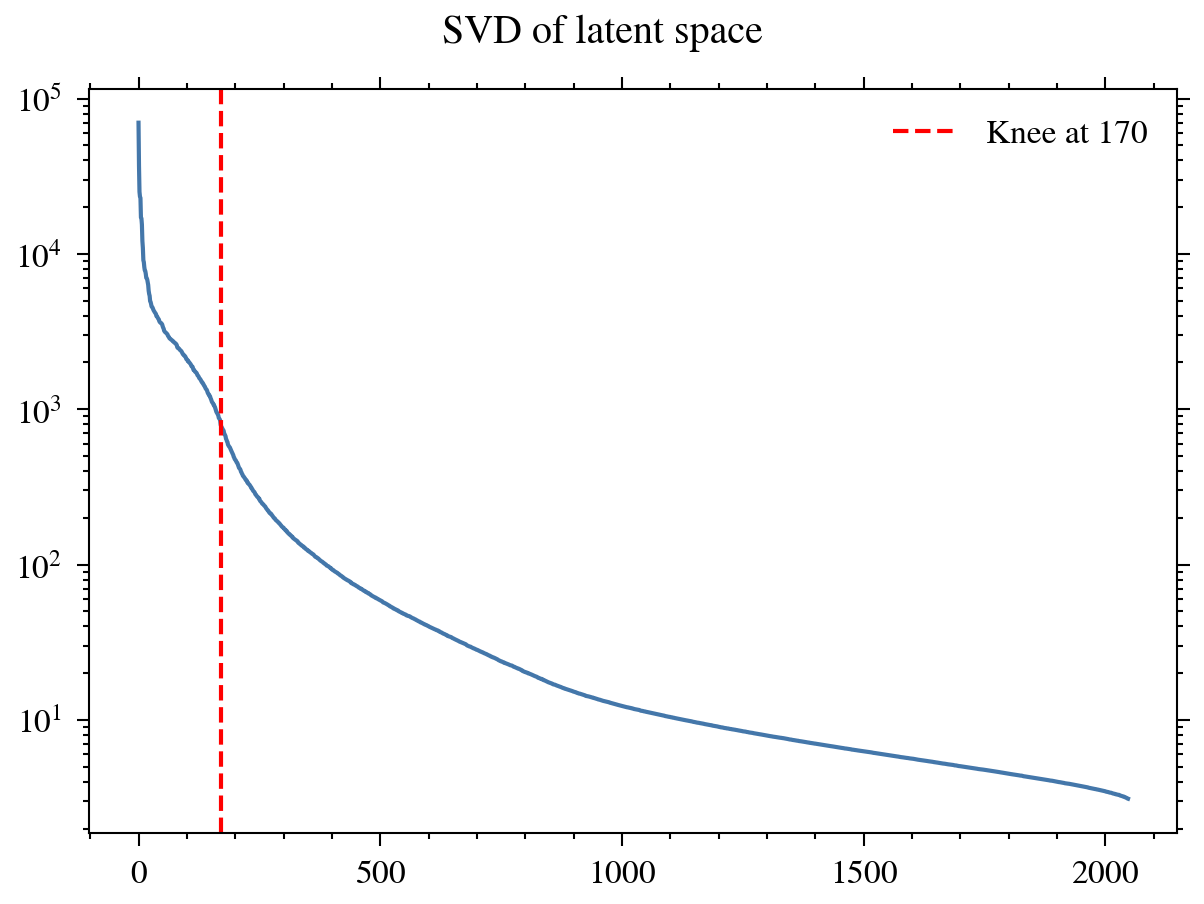

SVD Path: _data/autoencoder/svd/PPD_model_7_4_svd.npz
Knee at 170


In [140]:
svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of latent space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd_path}")
print(f"Knee at {k1.knee}")

In [141]:
tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out = int(k1.knee)
new_encode_latent_weights = (
    base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
)
new_encode_latent_biases = (
    base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
)
new_encode_linear = eqx.nn.Linear(
    in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.weight, new_encode_linear, new_encode_latent_weights
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers[-1],
    base_autoencoder,
    trained_new_encode_linear,
)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[
        :knee
    ]


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in = int(k1.knee)
new_decode_latent_weights = (
    sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
)
new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear = eqx.nn.Linear(
    in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.weight, new_decode_linear, new_decode_latent_weights
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers[2],
    sutured_ae_struct,
    trained_new_decode_linear,
)

sutured_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
)
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f"Suture Model Path: {sutured_model_path}")

encoder, decoder = sutured_ae.modules
# def sum2unity(X):
#     return X / np.sum(X, axis=(1, 2), keepdims=True)


# # sum2unity_layer = eqx.nn.Lambda(lambda z: sum2unity(z))
# # norm_sutured_ae = eqx.tree_at(
# #     lambda m: m.modules[1].layers,
# #     sutured_ae,
# #     sutured_ae.modules[1].layers + [sum2unity_layer],
# # )

# encoder, decoder = norm_sutured_ae.modules

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


Truth shape: (51, 51)
Decoded shape: (51, 51)
Max difference: 0.21427974104881287


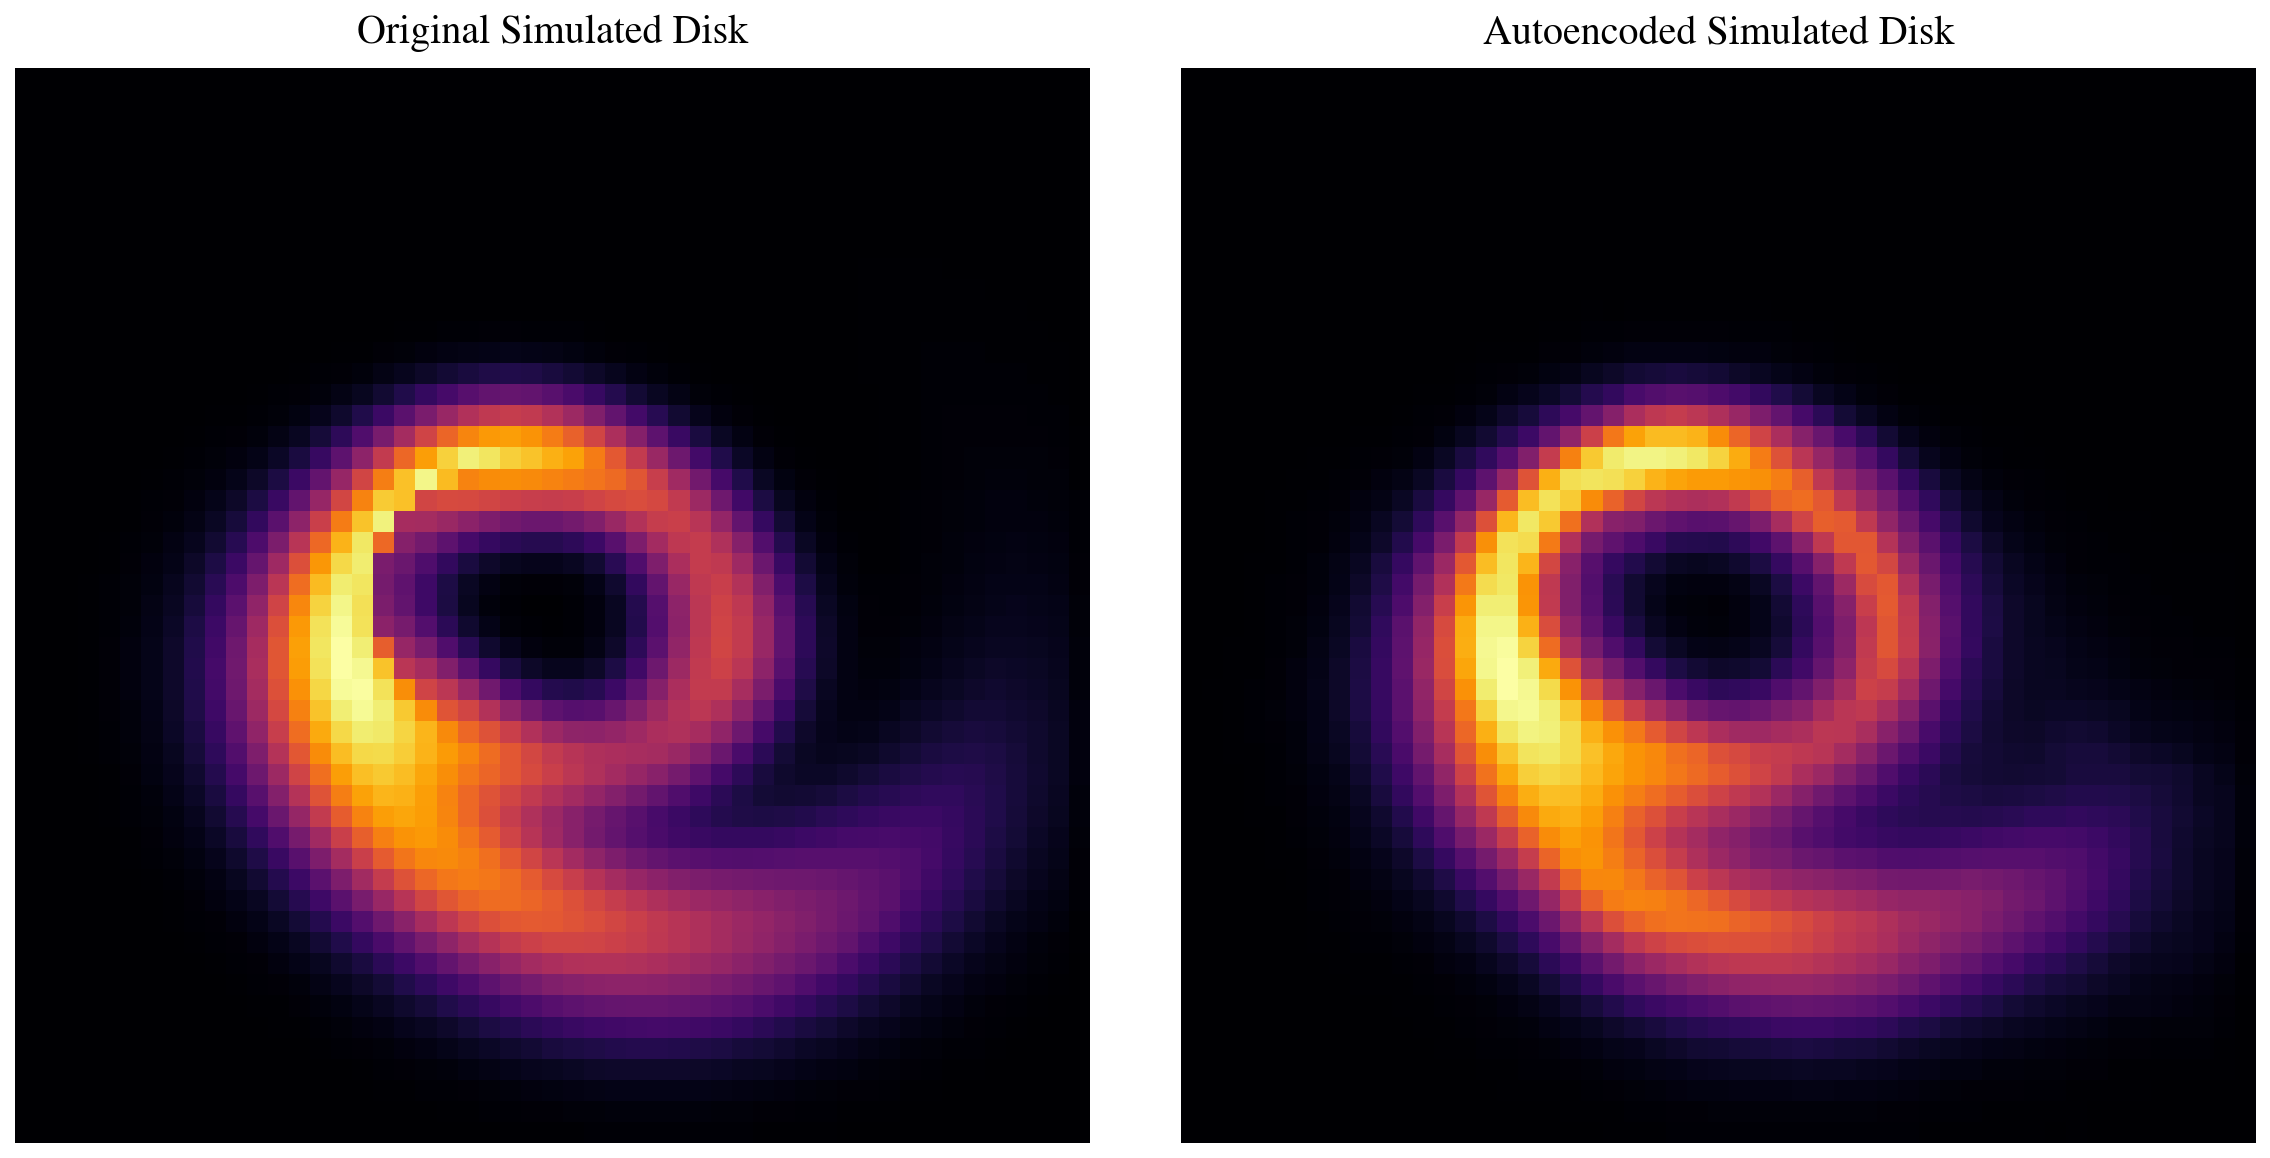

In [142]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), layout="tight")
ax[0].imshow(test_51x51_image)
ax[0].set_axis_off()
ax[0].set_title("Original Simulated Disk")
autoencoded_image = decoder(encoder(test_51x51_image.reshape(1, 51, 51)))[0]
ax[1].imshow(autoencoded_image)
ax[1].set_axis_off()
ax[1].set_title("Autoencoded Simulated Disk")

print(f"Truth shape: {test_51x51_image.shape}")
print(f"Decoded shape: {autoencoded_image.shape}")
print(f"Max difference: {np.abs(test_51x51_image - autoencoded_image).max()}")

Text(0.5, 1.0, 'Initial Distribution | Sum: 897.18896484375')

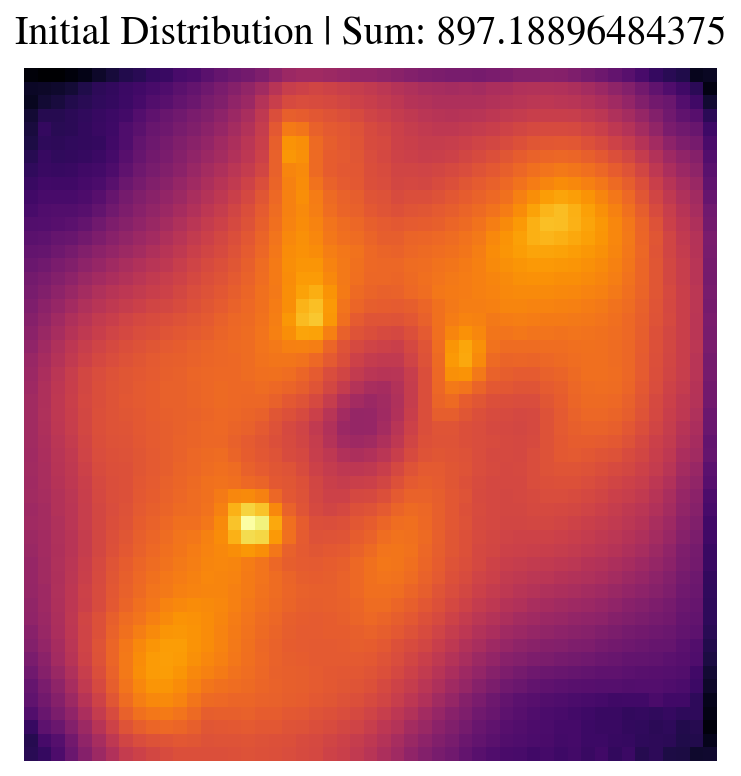

In [153]:
init_latent = np.zeros((170,))
init_dist = decoder(init_latent)[0]
# init_dist = normalize_image(test_51x51_image)
# init_dist = test_51x51_image
# init_latent = encoder(init_dist.reshape(1, 51, 51))
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(init_dist)
ax.set_axis_off()
ax.set_title(f"Initial Distribution | Sum: {np.sum(init_dist)}")

In [154]:
def Latent2CompleteVis(latent, decoder, u_grid, v_grid, pscale_mas, wavel):
    # Decode
    image = decoder(latent)[0]

    N_image = image.shape[0]
    pscale_rad = pscale_mas * mas2rad

    # Sky coordinates (radians, centered at 0)
    coords = (np.arange(N_image) - (N_image - 1) / 2.0) * pscale_rad

    # Handle both 1D and 2D grid inputs
    if u_grid.ndim == 1:
        # 1D arrays: create meshgrid internally
        uu, vv = np.meshgrid(u_grid, v_grid)
        u_flat = uu.flatten()
        v_flat = vv.flatten()
        output_shape = (len(v_grid), len(u_grid))  # (N_v, N_u)
        u_1d, v_1d = u_grid, v_grid
    else:
        # 2D grids: use as-is
        u_flat = u_grid.flatten()
        v_flat = v_grid.flatten()
        output_shape = u_grid.shape
        u_1d = u_grid[0, :]
        v_1d = v_grid[:, 0]

    # Convert baselines (metres) to spatial frequency (cycles/radian)
    u_freq = u_flat / wavel
    v_freq = v_flat / wavel

    # Build phase matrices
    two_pi = 2.0 * np.pi

    phase_alpha = np.exp(
        -1j * two_pi * np.outer(u_freq, coords)
    )  # (N_uv², N_image)
    phase_delta = np.exp(
        -1j * two_pi * np.outer(v_freq, coords)
    )  # (N_uv², N_image)

    # DFT via einsum
    V_flat = np.einsum("ki,ij,kj->k", phase_delta, image, phase_alpha)

    # Reshape to grid
    V_complete = V_flat.reshape(output_shape)

    return V_complete, u_1d, v_1d

In [155]:
def tv_regularization_isotropic(image, eps=1e-8):
    """
    Isotropic Total Variation: TV = sum(sqrt(dx^2 + dy^2))

    More standard formulation, but requires matching shapes.
    """
    # Compute gradients
    dx = np.diff(image, axis=1)  # (N, N-1)
    dy = np.diff(image, axis=0)  # (N-1, N)

    # Trim to matching shapes
    dx_trimmed = dx[:-1, :]  # (N-1, N-1)
    dy_trimmed = dy[:, :-1]  # (N-1, N-1)

    # Isotropic TV: sqrt of sum of squares
    # Add eps for numerical stability and differentiability at zero
    tv = np.sum(np.sqrt(dx_trimmed**2 + dy_trimmed**2 + eps))

    return tv


def loss_nll(
    z,
    decoder,
    V_data,
    u_grid,
    v_grid,
    pscale_mas,
    wavel,
    noise_var=None,
    alpha_tv=0.0,
):
    """
    Negative Log-Likelihood loss for complex visibility.

    For complex Gaussian noise: V_obs = V_true + noise
    where noise ~ CN(0, sigma^2) (complex normal)

    NLL = sum( |V_model - V_data|^2 / (2 * sigma^2) ) + const

    Args:
        z: latent vector
        decoder: image decoder
        V_data: (N_uv, N_uv) complex observed visibility
        noise_var: (N_uv, N_uv) noise variance at each (u,v) point
                    If None, assumes uniform noise (equivalent to chi2)
        alpha_tv: TV regularization strength
    """
    # Forward model
    V_model, _, _ = Latent2CompleteVis(
        z, decoder, u_grid, v_grid, pscale_mas, wavel
    )

    # Residual
    residual = V_model - V_data

    # Negative log-likelihood
    if noise_var is None:
        # Uniform noise: NLL ∝ sum |residual|^2
        # (up to constant that doesn't affect optimization)
        nll = np.sum(np.abs(residual) ** 2)
    else:
        # Weighted by inverse variance
        # NLL = 0.5 * sum( |residual|^2 / sigma^2 )
        # Also include log(sigma^2) term for proper likelihood
        nll = 0.5 * np.sum(
            np.abs(residual) ** 2 / noise_var + np.log(2 * np.pi * noise_var)
        )

    # Add TV regularization (acts as a prior)
    if alpha_tv > 0:
        image = decoder(z)
        tv = tv_regularization_isotropic(image)
        # In Bayesian terms: NLL - log(prior) = NLL + TV
        return nll + alpha_tv * tv

    return nll


In [156]:
N_image = 51
pscale_mas = 16.4
wavel = 3.823e-6

max_baseline_m = 6.5
N_uv = 1300

u1d, v1d = (
    np.linspace(-max_baseline_m, max_baseline_m, N_uv),
    np.linspace(-max_baseline_m, max_baseline_m, N_uv),
)
u_grid, v_grid = u1d, v1d

uu, vv = np.meshgrid(u1d, v1d)

V_data_clean, _, _ = Latent2CompleteVis(
    latent=None,  # not used
    decoder=lambda _: test_51x51_image.reshape(1, 51, 51),
    u_grid=u_grid,
    v_grid=v_grid,
    pscale_mas=pscale_mas,
    wavel=wavel,
)

#! Skipping noise for now
V_data = V_data_clean

In [157]:
# Test: image -> V should be self-consistent

# Forward model the truth twice
V1, _, _ = Latent2CompleteVis(None, lambda _: test_51x51_image.reshape(1, 51, 51), u_grid, v_grid, pscale_mas, wavel)
V2, _, _ = Latent2CompleteVis(None, lambda _: test_51x51_image.reshape(1, 51, 51), u_grid, v_grid, pscale_mas, wavel)

# Should be identical
print(f"V1 shape: {V1.shape}")
print(f"V2 shape: {V2.shape}")
print(f"Max difference: {np.abs(V1 - V2).max()}")
print(f"Are they identical? {np.allclose(V1, V2)}")

V1 shape: (1300, 1300)
V2 shape: (1300, 1300)
Max difference: 0.0
Are they identical? True


In [163]:
steps = 100
lr = 1e-2
alpha = 0.0
noise_var=None
optimizer = adam(lr)
opt_state = optimizer.init(init_latent)


In [164]:
def run_reconstruction(
    z_init,
    V_data,
    noise_var=noise_var,
    alpha_tv=alpha,
    n_steps=steps,
    learning_rate=lr,
    label="Reconstruction",
):
    """
    Run complete Fourier reconstruction with NLL loss.

    Args:
        noise_var: (N_uv, N_uv) variance map, or None for uniform noise
        alpha_tv: TV regularization strength
    """
    print(f"\n{'=' * 60}")
    print(f"{label}")
    print(f"  alpha_tv = {alpha_tv}")
    print(
        f"  noise model: {'heteroscedastic' if noise_var is not None else 'uniform'}"
    )
    print("=" * 60)

    optimizer = adam(learning_rate=learning_rate)
    opt_state = optimizer.init(z_init)

    z = z_init
    loss_history = []

    # Gradient of NLL
    grad_fn = jax.grad(loss_nll, argnums=0)

    with tqdm(total=n_steps, desc=label[:30]) as pbar:
        for step in range(n_steps):
            loss_val = loss_nll(
                z,
                decoder,
                V_data,
                u_grid,
                v_grid,
                pscale_mas,
                wavel,
                noise_var,
                alpha_tv,
            )

            grads = grad_fn(
                z,
                decoder,
                V_data,
                u_grid,
                v_grid,
                pscale_mas,
                wavel,
                noise_var,
                alpha_tv,
            )

            updates, opt_state = optimizer.update(grads, opt_state, z)
            z = apply_updates(z, updates)

            loss_history.append(float(loss_val))
            pbar.update(1)
            pbar.set_postfix({
                'loss': f'{loss_val:.3e}',
                'Δloss': f'{loss_history[-1] - loss_history[-2]:.2e}' if len(loss_history) > 1 else 'N/A'
            })

    image_recon = decoder(z)
    # image_recon = np.clip(image_recon, 0, None)
    # image_recon = image_recon / np.sum(image_recon)

    V_recon, _, _ = Latent2CompleteVis(
        z, decoder, u_grid, v_grid, pscale_mas, wavel
    )

    return {
        "z": z,
        "image": image_recon[0],
        "V": V_recon,
        "loss_history": loss_history,
        "label": label,
        "alpha_tv": alpha_tv,
    }

In [165]:
# Run without regularization (autoencoder prior only)
result_no_reg = run_reconstruction(
    init_latent,
    V_data,
    label="Autoencoder prior only",
)



Autoencoder prior only
  alpha_tv = 0.0
  noise model: uniform


Autoencoder prior only:   0%|          | 0/100 [00:00<?, ?it/s]

In [166]:
def plot_reconstruction(result, image_truth, V_data):
    """
    Comprehensive visualization of complete Fourier reconstruction.
    """
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.35)

    # ---- Row 1: Image comparison ----
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(image_truth, origin="lower", cmap="inferno")
    ax.set_title("Ground Truth", fontsize=11)
    ax.axis("off")

    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(result["image"], origin="lower", cmap="inferno")
    ax.set_title("Reconstruction", fontsize=11)
    ax.axis("off")

    ax = fig.add_subplot(gs[0, 2])
    residual = image_truth - result["image"]
    vmax = max(np.abs(residual).max(), 1e-3)
    im = ax.imshow(
        residual, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax
    )
    ax.set_title("Image Residual", fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

    # Metrics
    ax = fig.add_subplot(gs[0, 3])
    ax.axis("off")
    corr = float(
        np.corrcoef(image_truth.flatten(), result["image"].flatten())[0, 1]
    )
    rms = float(np.sqrt(np.mean((image_truth - result["image"]) ** 2)))

    metrics_text = "Image Metrics:\n\n"
    metrics_text += f"Correlation: {corr:.4f}\n"
    metrics_text += f"RMS error:   {rms:.4g}\n"
    metrics_text += f"\nFinal loss:  {result['loss_history'][-1]:.3g}"

    ax.text(
        0.05,
        0.95,
        metrics_text,
        transform=ax.transAxes,
        fontfamily="monospace",
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3),
    )

    # ---- Row 2: Complete visibility amplitude ----
    extent = [-max_baseline_m, max_baseline_m, -max_baseline_m, max_baseline_m]

    ax = fig.add_subplot(gs[1, 0])
    im = ax.imshow(
        np.abs(V_data), origin="lower", cmap="viridis", extent=extent
    )
    ax.set_xlabel("u [m]", fontsize=10)
    ax.set_ylabel("v [m]", fontsize=10)
    ax.set_title("|V| Data (complete)", fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, label="|V|")

    ax = fig.add_subplot(gs[1, 1])
    im = ax.imshow(
        np.abs(result["V"]), origin="lower", cmap="viridis", extent=extent
    )
    ax.set_xlabel("u [m]", fontsize=10)
    ax.set_title("|V| Model (complete)", fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, label="|V|")

    ax = fig.add_subplot(gs[1, 2])
    V_residual = np.abs(result["V"]) - np.abs(V_data)
    vmax_V = np.abs(V_residual).max()
    im = ax.imshow(
        V_residual,
        origin="lower",
        cmap="RdBu_r",
        vmin=-vmax_V,
        vmax=vmax_V,
        extent=extent,
    )
    ax.set_xlabel("u [m]", fontsize=10)
    ax.set_title("|V| Residual", fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, label="Δ|V|")

    # Radial visibility profile
    ax = fig.add_subplot(gs[1, 3])

    # Compute radial distance
    V_shape = V_data.shape
    u_1d = np.linspace(-max_baseline_m, max_baseline_m, V_shape[1])
    v_1d = np.linspace(-max_baseline_m, max_baseline_m, V_shape[0])
    uu, vv = np.meshgrid(u_1d, v_1d)
    uv_dist = np.sqrt(uu**2 + vv**2)

    bins = np.linspace(0, uv_dist.max(), 25)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    V_data_radial = []
    V_model_radial = []
    for i in range(len(bins) - 1):
        mask = (uv_dist >= bins[i]) & (uv_dist < bins[i + 1])
        V_data_radial.append(np.mean(np.abs(V_data[mask])))
        V_model_radial.append(np.mean(np.abs(result["V"][mask])))

    ax.plot(
        bin_centers, V_data_radial, "o-", label="Data", markersize=4, alpha=0.7
    )
    # ax.plot(
    #     bin_centers,
    #     V_model_radial,
    #     "s-",
    #     label="Model",
    #     markersize=4,
    #     alpha=0.7,
    # )
    ax.set_xlabel("Baseline |uv| [m]", fontsize=10)
    ax.set_ylabel("|V| (azimuthal avg)", fontsize=10)
    ax.set_title("Radial Profile", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ---- Row 3: Phase and loss curve ----
    ax = fig.add_subplot(gs[2, 0])
    im = ax.imshow(
        np.angle(V_data),
        origin="lower",
        cmap="twilight",
        vmin=-np.pi,
        vmax=np.pi,
        extent=extent,
    )
    ax.set_xlabel("u [m]", fontsize=10)
    ax.set_ylabel("v [m]", fontsize=10)
    ax.set_title("arg(V) Data", fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, label="phase [rad]")

    ax = fig.add_subplot(gs[2, 1])
    im = ax.imshow(
        np.angle(result["V"]),
        origin="lower",
        cmap="twilight",
        vmin=-np.pi,
        vmax=np.pi,
        extent=extent,
    )
    ax.set_xlabel("u [m]", fontsize=10)
    ax.set_title("arg(V) Model", fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, label="phase [rad]")

    # Loss curve
    ax = fig.add_subplot(gs[2, 2:])
    ax.semilogy(result["loss_history"], linewidth=2, color="C0")
    ax.set_xlabel("Optimization step", fontsize=10)
    ax.set_ylabel("Loss", fontsize=10)
    ax.set_title("LOSS", fontsize=11)
    ax.grid(alpha=0.3)

    plt.suptitle(
        "Complete Fourier Reconstruction", fontsize=13, fontweight="bold"
    )

    return fig

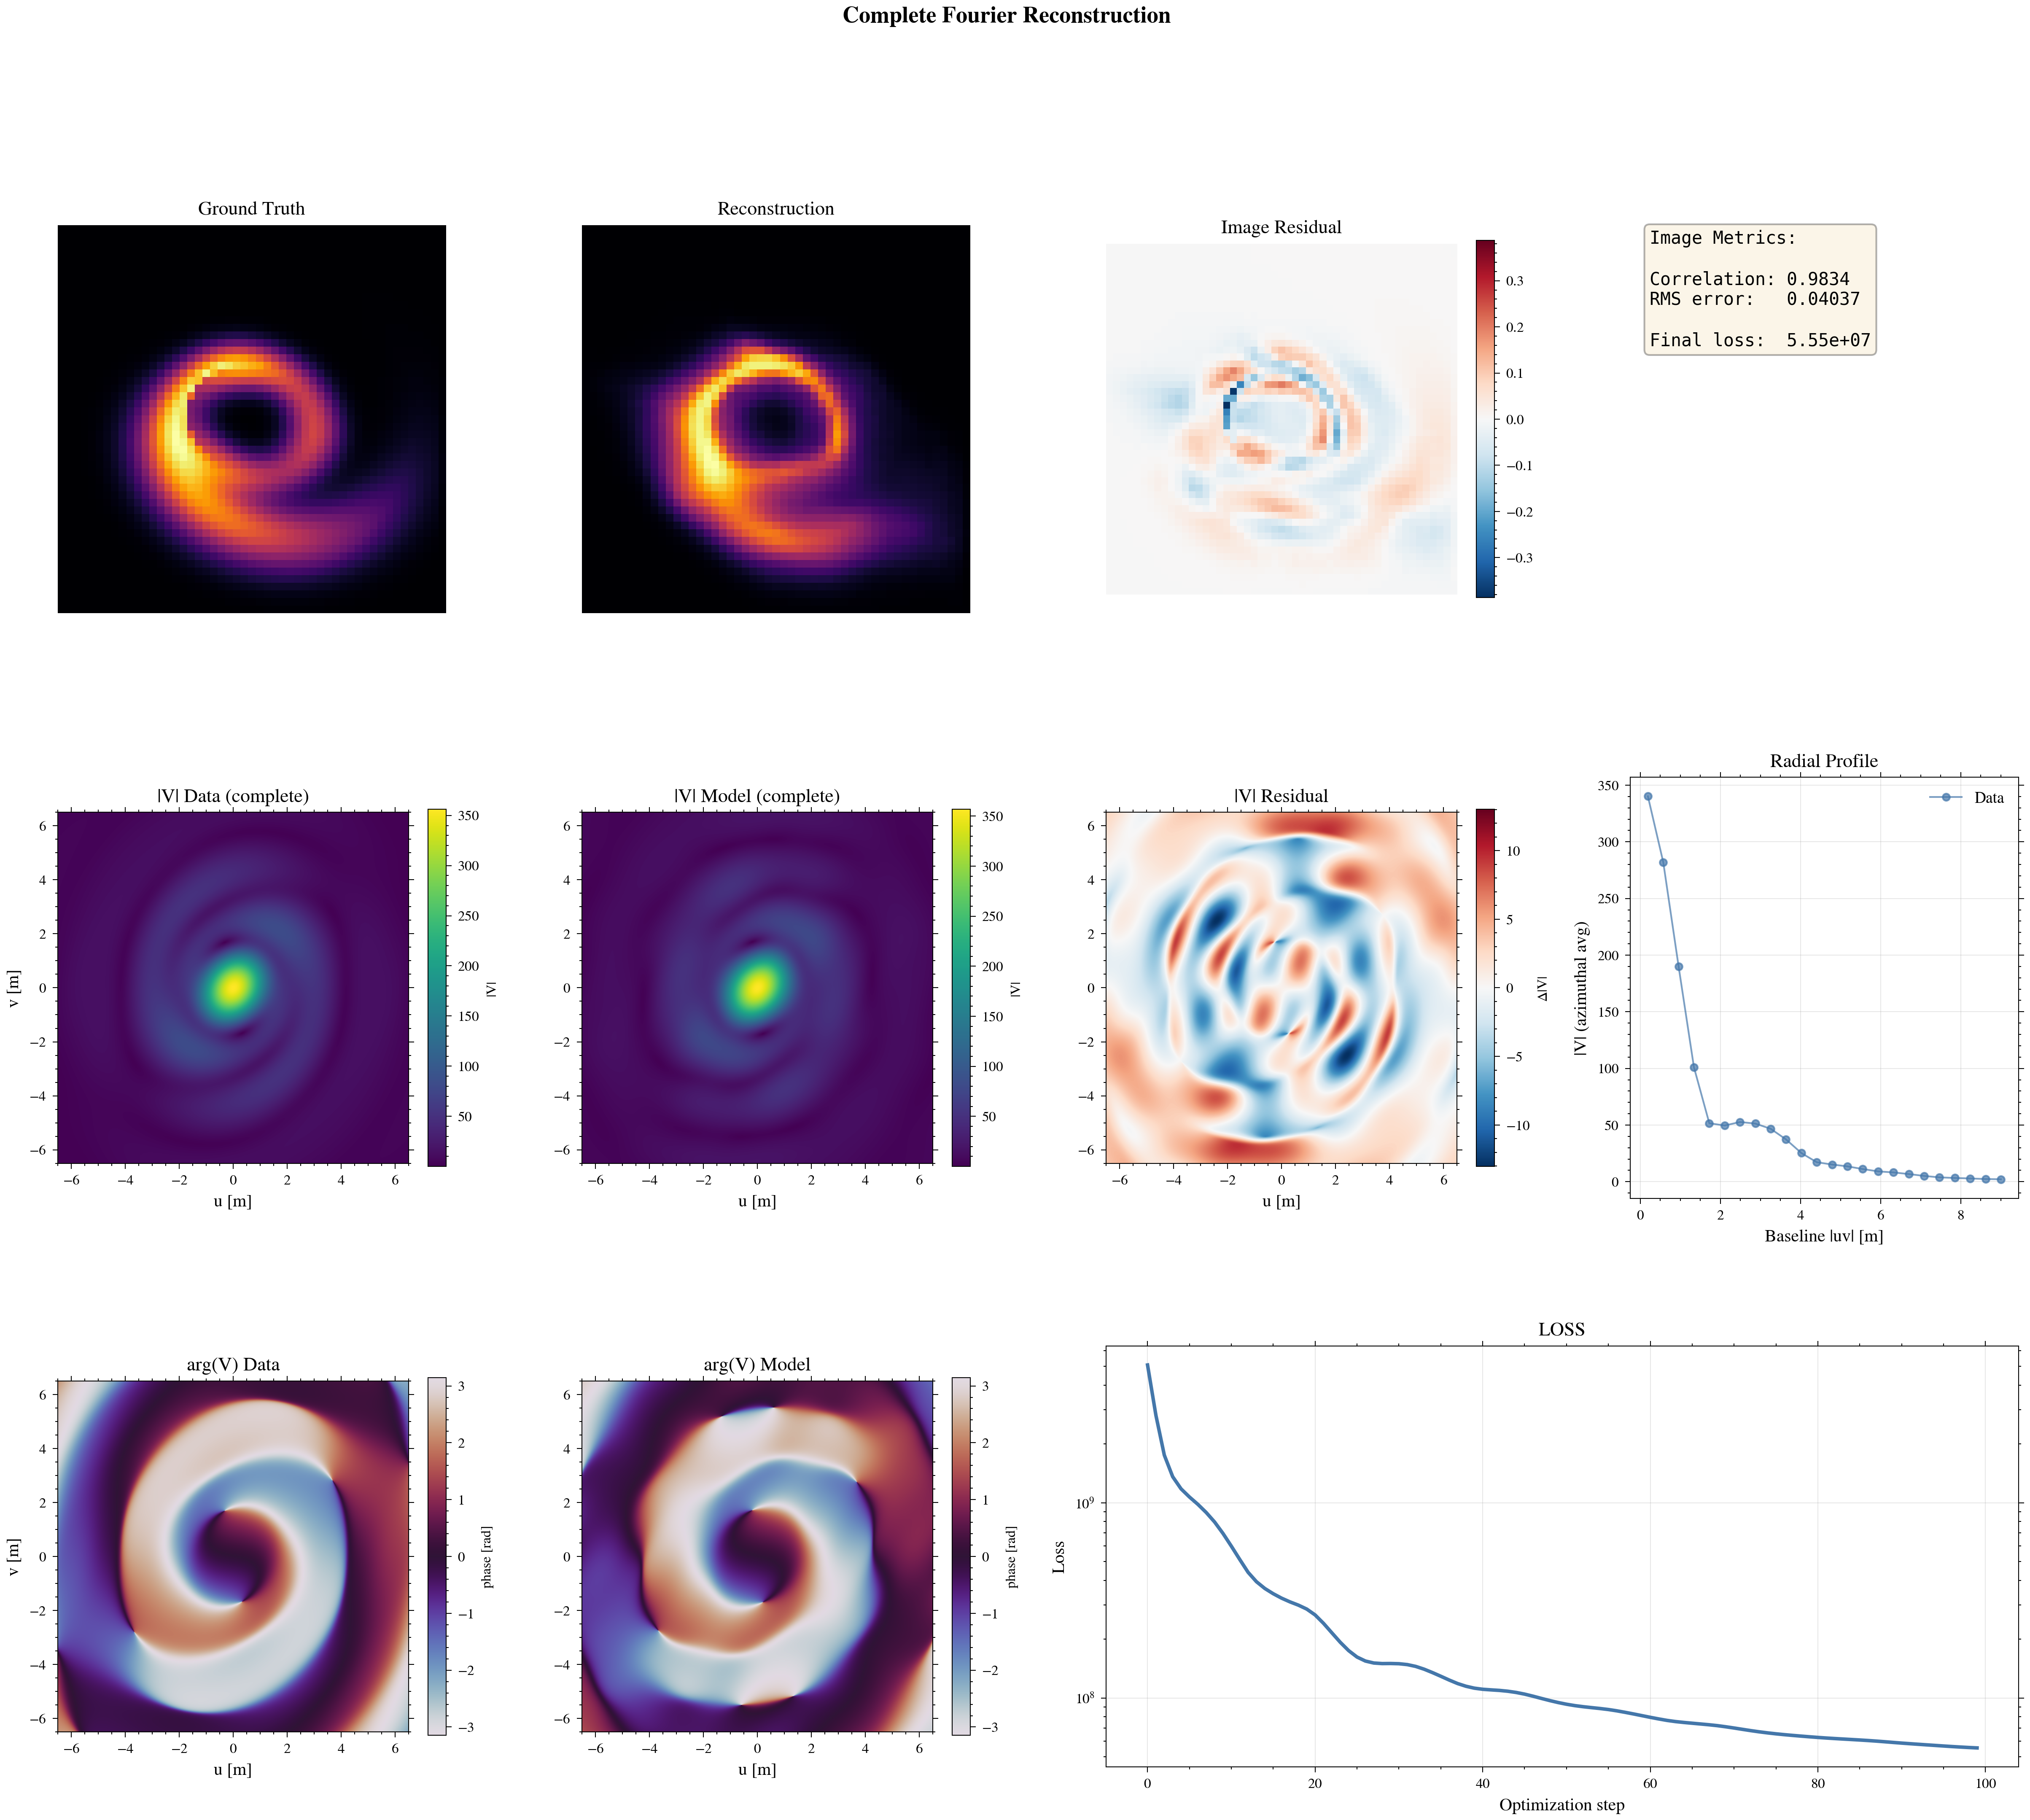


RECONSTRUCTION SUMMARY

Image correlation:     0.9834
Image RMS error:       0.04037
Visibility RMS error:  5.71556
Final loss:            5.55e+07

Convergence: 5.08e+09 → 5.55e+07


In [167]:
# After running your reconstruction:
result = result_no_reg
fig = plot_reconstruction(result, test_51x51_image, V_data)
# plt.savefig('reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print("\n" + "=" * 60)
print("RECONSTRUCTION SUMMARY")
print("=" * 60)

corr = np.corrcoef(test_51x51_image.flatten(), result["image"].flatten())[0, 1]
rms = np.sqrt(np.mean((test_51x51_image - result["image"]) ** 2))
V_rms = np.sqrt(np.mean(np.abs(result["V"] - V_data) ** 2))

print(f"\nImage correlation:     {corr:.4f}")
print(f"Image RMS error:       {rms:.5f}")
print(f"Visibility RMS error:  {V_rms:.5f}")
print(f"Final loss:            {result['loss_history'][-1]:.3g}")
print(
    f"\nConvergence: {result['loss_history'][0]:.3g} → {result['loss_history'][-1]:.3g}"
)